# KIMI_CXR – Agent auf einem Röntgenbild ausführen (Colab)

Dieses Notebook startet den **CXR-Agenten** und analysiert **ein** Bild.

**Was passiert beim Ausführen?**
Bild (PNG/JPG/DICOM) → dein selbst trainierter **Classifier** (15 Wahrscheinlichkeiten) + **Grad-CAM-Heatmap** → **Anatomie-Lokalisation** (TorchXRayVision: rechte/linke Lunge, Ober-/Mittel-/Unterfeld, Herz, Mediastinum) → **View** (AP/PA/lateral, ianpan) → **Support-Device-Check** → eine zusammenfassende Antwort.

**Voraussetzungen**
1. Du hast den Classifier bereits trainiert → `weights/classifier/best_model.pt` liegt auf Drive (im Projektordner).
2. Laufzeit-Typ = **GPU (T4)** (Menü: *Laufzeit → Laufzeittyp ändern → T4 GPU*).

> Hinweis: Forschungs-/Entwicklungsprojekt, **nicht klinisch validiert**. Keine medizinische Diagnose.

**So benutzt du das Notebook:** Zellen der Reihe nach ausführen. Nur in **Schritt 2** trägst du den Pfad zu deinem Bild ein.

## Schritt 0 – Google Drive einbinden & in den Projektordner wechseln

Falls dein Projekt woanders liegt, passe den Pfad in der `%cd`-Zeile an (er muss auf den Ordner zeigen, der `config.py` und `medrax/` enthält).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# >>> Bei Bedarf anpassen: Pfad zum Projektordner (enthält config.py + medrax/) <<<
%cd /content/drive/MyDrive/Colab/IKIM_CXR

!ls   # zur Kontrolle: hier sollten config.py, medrax, scripts, weights ... auftauchen

Mounted at /content/drive
/content/drive/MyDrive/Colab/IKIM_CXR
config_old.py  logs    notebooks    pyproject.toml    scripts  weights
config.py      medrax  outputs	    README.md	      src
data	       models  __pycache__  requirements.txt  tmp


## Schritt 1 – Agent-Tools installieren (einmal pro Sitzung)

Diese Pakete aktivieren die Zusatz-Tools (Anatomie-Segmenter, View-Klassifikation, Support-Device).
Beim **ersten** Aufruf des Agenten werden zusätzlich deren Modellgewichte automatisch heruntergeladen (einmalig).

*Hinweis:* Auch ohne diese Pakete läuft der Agent – dann aber nur mit Classifier + Grad-CAM (ohne View/Anatomie/Device).

In [2]:
# Falls pydicom/pylibjpeg in der Session fehlen (für DICOM-Eingaben):
!pip -q install pydicom pylibjpeg pylibjpeg-openjpeg pylibjpeg-libjpeg python-dotenv scikit-image
# Zusatz-Tools des Agenten:
!pip -q install torchxrayvision "transformers<5" timm einops huggingface_hub safetensors "albumentations<1.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 118.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 12.9 MB/s eta 0:00:00


## Schritt 2 – Welches Bild soll analysiert werden? (HIER eintragen)

**Wo darf das Bild liegen?** Überall, worauf Colab in dieser Sitzung zugreifen kann:
- auf **Google Drive**, z. B. `/content/drive/MyDrive/Colab/IKIM_CXR/data/VinBigData/test/<id>.dicom`
- im **lokalen Colab-Speicher** `/content/...` (z. B. ein bereits dekodiertes Trainingsbild `/content/train_png/<id>.png`)
- ein **hochgeladenes** Bild (siehe optionale Upload-Zelle direkt darunter) → liegt dann unter `/content/<dateiname>`

**Welche Formate?** PNG, JPG oder DICOM (`.dcm` / `.dicom`).

Trage unten bei `IMAGE` den vollständigen Pfad ein.

In [3]:
import os

# >>>>>>>>>>>>>>>>>>  Hey Florian: HIER BITTE BILDPFAD EINTRAGEN  <<<<<<<<<<<<<<<<<<
IMAGE = "/content/drive/MyDrive/Colab/IKIM_CXR/data/VinBigData/test/0cf83a19a8281e4a281dece9854008ac.dicom"
#
# Beispiele:
#   DICOM auf Drive : ".../data/VinBigData/test/<image_id>.dicom"
#   Trainings-PNG   : "/content/train_png/<image_id>.png"
#   Hochgeladen     : "/content/mein_bild.png"

QUESTION = "Was siehst du auf diesem Röntgenbild?"   # Frage an den Agenten
IMG_SIZE = 384   # Inferenz-Auflösung – sollte zur Trainingsauflösung passen (du hast 384 trainiert)

print("Bild existiert:", os.path.exists(IMAGE))
print("Pfad:", IMAGE)
assert os.path.exists(IMAGE), "Bild nicht gefunden – Pfad oben korrigieren (oder Upload-Zelle nutzen)."

Bild existiert: True
Pfad: /content/drive/MyDrive/Colab/IKIM_CXR/data/VinBigData/test/0cf83a19a8281e4a281dece9854008ac.dicom


In [4]:
!pip -q install transformers accelerate fastapi uvicorn openai requests

In [5]:
import torch, requests, openai

print("torch:", torch.__version__)
print("CUDA verfügbar:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "keine")

try:
    import vllm
    print("vLLM import ok:", vllm.__version__)
except Exception as e:
    print("vLLM import FEHLER:")
    print(e)

torch: 2.11.0+cu128
CUDA verfügbar: True
GPU: NVIDIA L4
vLLM import FEHLER:
No module named 'vllm'


### (Optional) Bild direkt vom Rechner hochladen

Falls dein Bild noch nicht in Colab/Drive liegt: diese Zelle ausführen, Datei auswählen – `IMAGE` wird automatisch gesetzt. (Wenn du schon einen Pfad in Schritt 2 hast, kannst du diese Zelle überspringen.)

In [ ]:
# from google.colab import files
# up = files.upload()                      # öffnet einen Datei-Dialog
# IMAGE = "/content/" + list(up.keys())[0]
# print("Hochgeladen und gesetzt:", IMAGE)

## Schritt 2.5 – Unsupervised Sprach-Training auf Radiologieberichten

Hier lernt Qwen **unsupervised** (reines Next-Token-Prediction, **keine Labels**) den
Sprachstil radiologischer Befunde – trainiert auf bereinigten **CheXpert-Plus**-Berichten
(nur `FINDINGS` + `IMPRESSION`, dedupliziert, englisch normalisiert).

Es wird ein **LoRA-Adapter** erzeugt (Basismodell bleibt eingefroren → die Instruktions-
Fähigkeit, die der Agent braucht, bleibt erhalten; nur der Stil wird angepasst).

**Ablauf:** Korpus bauen (einmalig) → LoRA-Training (~30–60 min auf T4) → Adapter auf Drive.
Beide Schritte **überspringen automatisch**, wenn Korpus/Adapter schon existieren.

> Voraussetzung: Der `data/chexpert/`-Ordner mit der CSV liegt auf Drive im Projekt.

In [6]:
# Trainings-Abhängigkeiten (LoRA continued pretraining):
!pip -q install peft datasets

In [7]:
import os
CORPUS    = "data/chexpert/processed/reports_corpus.jsonl"
N_REPORTS = 20000   # Anzahl Berichte fürs Training (einstellbar)

if os.path.exists(CORPUS):
    print("Korpus existiert bereits -> Aufbereitung übersprungen:", CORPUS)
else:
    # Parst CheXpert-CSV (nur FINDINGS + IMPRESSION), säubert/normalisiert, dedupliziert.
    cmd = f'python -m medrax.llm.prepare_reports --max-samples {N_REPORTS} --out "{CORPUS}"'
    print("Run:", cmd)
    get_ipython().system(cmd)

Run: python -m medrax.llm.prepare_reports --max-samples 20000 --out "data/chexpert/processed/reports_corpus.jsonl"
 QUALITÄTSKONTROLLE – CheXpert-Berichte (section_findings + section_impression)
CSV: /content/drive/MyDrive/Colab/IKIM_CXR/data/chexpert/metadata/table_subsets/df_chexpert_plus_240401.csv
Out: data/chexpert/processed/reports_corpus.jsonl

------------------ BEISPIEL 1 ------------------
FINDINGS: Costophrenic angles sharp, without evidence of effusion. The cardiomediastinal silhouette is normal. Vessels mildly indistinct with prominence of interstitial structures, suggesting mild, pulmonary edema. Left subclavian central venous catheter is seen, tip in mid SVC. No pneumothorax.
IMPRESSION: 1. No evidence of pneumothorax. 2. Mild interstitial pulmonary edema.

------------------ BEISPIEL 2 ------------------
IMPRESSION: Low lung volumes, and overlying trauma board limit evaluation. There is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac o

In [9]:
 !pip -q uninstall -y torchao

In [10]:
import os

# Fix für Colab: vorinstalliertes torchao 0.10 ist zu alt und lässt peft beim
# LoRA-Erstellen abbrechen. torchao wird hier nicht gebraucht -> entfernen.
get_ipython().system('pip -q uninstall -y torchao')

ADAPTER  = "weights/llm/qwen_reports_lora"
BASE_LLM = "Qwen/Qwen2.5-1.5B-Instruct"

if os.path.exists(os.path.join(ADAPTER, "adapter_config.json")):
    print("LoRA-Adapter existiert bereits -> Training übersprungen:", ADAPTER)
else:
    cmd = f'python -m medrax.llm.train_lm_unsupervised --base-model {BASE_LLM} --corpus "{CORPUS}" --out "{ADAPTER}" --epochs 1'
    print("Run:", cmd)
    get_ipython().system(cmd)

import gc, torch
gc.collect(); torch.cuda.empty_cache()
print("Training-Schritt fertig. GPU-Speicher freigegeben. Adapter:", ADAPTER)

Run: python -m medrax.llm.train_lm_unsupervised --base-model Qwen/Qwen2.5-1.5B-Instruct --corpus "data/chexpert/processed/reports_corpus.jsonl" --out "weights/llm/qwen_reports_lora" --epochs 1
2026-06-09 10:53:36.229572: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 10:53:36.300853: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[train-lm] Basis-Modell: Qwen/Qwen2.5-1.5B-Instruct
[train-lm] Korpus: data/chexpert/processed/reports_corpus.jsonl
[train-lm] Modus: fp16 LoRA
`torch_dtype` is deprecated! Use `dty

## Schritt 3 – LLM-Server (stil-adaptiertes Qwen)

Startet einen lokalen OpenAI-kompatiblen Server (`medrax/llm/serve_qwen.py`), der das
Basismodell **Qwen2.5-1.5B-Instruct** lädt und – falls in Schritt 2.5 trainiert – den
**LoRA-Adapter** darauflegt. Dadurch spricht der Agent im radiologischen Befund-Stil
(Findings/Impression, **auf Englisch**).

In [11]:
import os, sys, subprocess, time, requests

BASE_LLM = "Qwen/Qwen2.5-1.5B-Instruct"
ADAPTER  = "weights/llm/qwen_reports_lora"   # stil-adaptiertes Qwen aus Schritt 2.5

# Port 8000 freimachen (falls belegt)
get_ipython().system('fuser -k 8000/tcp || true')

log_file = open("/content/qwen_server.log", "w")
cmd = [sys.executable, "medrax/llm/serve_qwen.py", "--model", BASE_LLM, "--port", "8000"]
if os.path.isdir(ADAPTER):
    cmd += ["--adapter", ADAPTER]
    print("Server nutzt den LoRA-Adapter (stil-adaptiert):", ADAPTER)
else:
    print("Kein Adapter gefunden -> Server nutzt nur das Basismodell.")

server = subprocess.Popen(cmd, stdout=log_file, stderr=log_file)
print("Starte lokalen Qwen-Server (transformers)... Modell-Laden dauert 1-3 min.")

for i in range(240):
    try:
        if requests.get("http://127.0.0.1:8000/health", timeout=2).status_code == 200:
            print("Qwen-Server läuft.")
            break
    except Exception:
        pass
    if i % 15 == 0:
        print(f"Warte... {i*2}s")
    time.sleep(2)
else:
    print("Server nicht gestartet. Letzter Log:")
    get_ipython().system('tail -n 100 /content/qwen_server.log')
    raise RuntimeError("Qwen-Server konnte nicht gestartet werden.")

os.environ["OPENAI_BASE_URL"] = "http://127.0.0.1:8000/v1"
os.environ["OPENAI_API_KEY"]  = "dummy"
os.environ["OPENAI_MODEL"]    = BASE_LLM
print("OPENAI_BASE_URL:", os.environ["OPENAI_BASE_URL"], "| MODEL:", BASE_LLM)

Server nutzt den LoRA-Adapter (stil-adaptiert): weights/llm/qwen_reports_lora
Starte lokalen Qwen-Server (transformers)... Modell-Laden dauert 1-3 min.
Warte... 0s
Qwen-Server läuft.
OPENAI_BASE_URL: http://127.0.0.1:8000/v1 | MODEL: Qwen/Qwen2.5-1.5B-Instruct


In [12]:
from openai import OpenAI
import os

client = OpenAI(base_url=os.environ["OPENAI_BASE_URL"], api_key=os.environ["OPENAI_API_KEY"])

resp = client.chat.completions.create(
    model=os.environ["OPENAI_MODEL"],
    messages=[
        {"role": "system", "content": "You are a chest X-ray reporting assistant. Answer in English, in radiology report style."},
        {"role": "user", "content": "Summarize briefly: cardiomegaly likely, no pneumothorax."},
    ],
    max_tokens=120,
    temperature=0.2,
)

print(resp.choices[0].message.content)

Cardiomegaly is likely with no evidence of tension or pleural effusion.


## Schritt 4 – Agent starten und Bild analysieren

Lädt die Tools (beim 1. Mal inkl. Modell-Downloads) und analysiert `IMAGE`.

In [13]:
import os, sys, importlib

QWEN_BASE_URL = "http://127.0.0.1:8000/v1"
QWEN_API_KEY  = "dummy"
QWEN_MODEL    = "Qwen/Qwen2.5-1.5B-Instruct"

os.environ["OPENAI_BASE_URL"] = QWEN_BASE_URL
os.environ["OPENAI_API_KEY"]  = QWEN_API_KEY
os.environ["OPENAI_MODEL"]    = QWEN_MODEL

sys.path.insert(0, os.getcwd())

import medrax.agent.qwen_client as qwen_client
qwen_client = importlib.reload(qwen_client)

# Die tatsächlich vom QwenClient genutzte Config überschreiben
qwen_client.config.OPENAI_BASE_URL = QWEN_BASE_URL
qwen_client.config.OPENAI_API_KEY  = QWEN_API_KEY
qwen_client.config.OPENAI_MODEL    = QWEN_MODEL

import medrax.agent.initialize_agent as initialize_agent_module
initialize_agent_module = importlib.reload(initialize_agent_module)

print("QwenClient-Config gesetzt:", qwen_client.config.OPENAI_MODEL, "@", qwen_client.config.OPENAI_BASE_URL)

QwenClient-Config gesetzt: Qwen/Qwen2.5-1.5B-Instruct @ http://127.0.0.1:8000/v1


In [14]:
from medrax.agent.initialize_agent import initialize_agent

agent = initialize_agent()

res = agent.analyze_image(IMAGE, question=QUESTION)

print("\n" + "="*70)
print(" ANTWORT")
print("="*70)
print(res["answer"])

print("\n----- Strukturierte Signale -----")
print("LLM genutzt :", res["llm_ok"], "(False = kein LLM -> Fallback-Text)")
print("Top-5       :", res["top"])

view = res.get("view") or {}
print("View        :", view.get("view"), "| CTR:", view.get("cardiothoracic_ratio"))

loc = res.get("localization") or {}
print("Lokalisation:", loc.get("localized"), "| Zone:", loc.get("zone"), "| Methode:", loc.get("method"))

sup = res.get("support_device") or {}
print("Support-Dev :", sup.get("present"), "| Confidence:", sup.get("confidence"))

print("Grad-CAM    :", res["heatmap_path"])

[agent] Initialisiere Tools: ['DicomProcessorTool', 'ImageVisualizerTool', 'MyChestXRayClassifierTool', 'XRVAnatomySegmenterTool', 'ChestXrayBasicTool', 'SupportDeviceClassifierTool']
[tools] geladen: DicomProcessorTool
[tools] geladen: ImageVisualizerTool
[tools] geladen: MyChestXRayClassifierTool
[tools] geladen: XRVAnatomySegmenterTool
[tools] geladen: ChestXrayBasicTool
[tools] geladen: SupportDeviceClassifierTool
[agent] LLM: Qwen/Qwen2.5-1.5B-Instruct @ http://127.0.0.1:8000/v1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/708 [00:00<?, ?B/s]

configuration.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- unet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/ianpan/chest-x-ray-basic:
- modeling.py
- unet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/89.1M [00:00<?, ?B/s]

[chest-x-ray-basic] Modell geladen.
If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/pspnet_chestxray_best_model_4.pth -O /root/.torchxrayvision/models_data/pspnet_chestxray_best_model_4.pth`
[██████████████████████████████████████████████████]
[xrv-anatomy] PSPNet geladen. Targets: 14


pytorch_model.safetensors:   0%|          | 0.00/28.3M [00:00<?, ?B/s]

[support-device] CheXpert-DenseNet121 geladen.

 ANTWORT
**Results from Chest X-ray (CXR)**

**Projection:** PA view, with the patient's right lung fully included and the left lung partially included. The heart size appears within normal limits given the limited projection.

**Support Device:** No evidence of a supporting device on this examination.

**Findings:**  
1. **Increased Probability of Infiltration**: There is marked increase in the probability of pulmonary infiltrates compared to prior studies. This could represent worsening infection or edema.
2. **Pulmonary Fibrosis**: Probable mild interstitial pulmonary edema with probable mild pulmonary fibrosis. 
3. **Lung Opacity**: Possible small bilateral pleural effusions.  
4. **Nodule/Mass**: Increased probability of nodular opacities in both lungs, which could be related to chronic changes or infectious processes.

----- Strukturierte Signale -----
LLM genutzt : True (False = kein LLM -> Fallback-Text)
Top-5       : [('Infiltrat

In [ ]:
!grep -R "localhost:11434\|qwen3:1.7b\|OPENAI_BASE_URL\|OPENAI_MODEL\|LLM" -n medrax | head -100

grep: medrax/agent/__pycache__/qwen_client.cpython-311.pyc: binary file matches
medrax/__init__.py:9:  * Qwen-LLM-Agent (Ollama, OpenAI-kompatibel) für radiologen-artige Zusammenfassung
medrax/agent/qwen_client.py:2:Qwen-LLM-Client (OpenAI-kompatibel, lokal via Ollama).
medrax/agent/qwen_client.py:4:- Liest OPENAI_BASE_URL / OPENAI_API_KEY / OPENAI_MODEL aus config (.env/Umgebung).
medrax/agent/qwen_client.py:7:  "LLM unreachable / Ollama server not running" zurückgegeben.
medrax/agent/qwen_client.py:33:        self.base_url = (base_url or config.OPENAI_BASE_URL).rstrip("/")
medrax/agent/qwen_client.py:35:        self.model = model or config.OPENAI_MODEL
medrax/agent/qwen_client.py:36:        self.timeout = timeout or config.LLM_TIMEOUT
medrax/agent/qwen_client.py:46:            "error": "LLM unreachable / Ollama server not running",
medrax/agent/qwen_client.py:51:                "oder passe OPENAI_BASE_URL/OPENAI_MODEL in .env an."
medrax/agent/initialize_agent.py:78:        """Strukt

## Schritt 5 – Grad-CAM-Heatmap anzeigen

Zeigt, welche Bildregion die wahrscheinlichste Pathologie ausgelöst hat (Overlay).

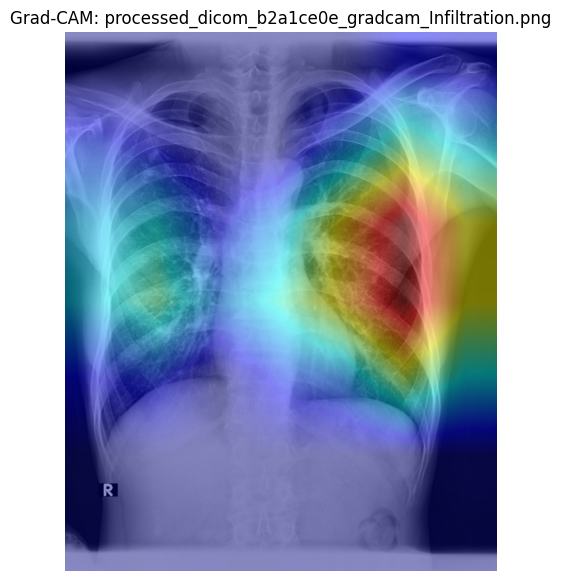

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

hp = res.get("heatmap_path")
if hp and os.path.exists(hp):
    plt.figure(figsize=(7, 7))
    plt.imshow(Image.open(hp))
    plt.axis("off")
    plt.title("Grad-CAM: " + os.path.basename(hp))
    plt.show()
else:
    print("Keine Heatmap erzeugt.")

## Wie sind die Ausgaben zu lesen?

- **Top-5 / Wahrscheinlichkeiten**: Screening-Hinweise deines Classifiers (VinBigData-15) – **keine** Diagnose, **keine** Objektdetektion. Hohe `No finding`-Wahrscheinlichkeit spricht gegen Befunde.
- **View**: Aufnahme-Projektion (AP/PA/lateral) + grobe Lunge/Herz-Erkennung (ianpan); `CTR` ≈ kardiothorakaler Quotient (> ~0,5 kann auf eine vergrößerte Herzsilhouette hindeuten).
- **Lokalisation**: nur gesetzt (`localized = True`), wenn eine Pathologie wahrscheinlich **und** eine anatomische Zone klar dominant **und** die Heatmap fokussiert ist – sonst bewusst **keine** Zonen-Aussage.
- **Support-Device**: grobe Ja/Nein-Einschätzung (CheXpert-DenseNet), ob ein Tubus/Katheter/Schrittmacher o. ä. sichtbar ist.
- **Antwort**: Fließtext (mit LLM) bzw. strukturierte Zusammenfassung (ohne LLM).

**Ergebnis-Dateien** (auf Drive im Projektordner): Grad-CAM-Overlay unter `outputs/visualizations/`.

> Erneut testen: einfach in **Schritt 2** einen anderen `IMAGE`-Pfad setzen und Schritt 4 + 5 erneut ausführen.
>
> **Nicht klinisch validiert – nur Forschung/Entwicklung.**